# 회귀모델

> 회귀(regression)는 숫자 값을 예측하는 머신러닝 문제입니다.

**머신러닝 문제**
|구분|예측 결과|예시|
|---|---|---|
|분류(classification)|범주,클래스|합격/불합격, 스팸/정상|
|회귀(regression)|연속적인 숫자|시험 점수, 매출액, 배송시간|

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

#머신러닝 도구
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

**실습 데이터 만들기**

학생의 공부시간, 출력율, 과제점수로 최종 시험 점수를 예측하기

In [ ]:
student_df=pd.DataFrame({
    "study_hours":[1,2,3,4,5],
    "attendance":[10,20,30,40,50],
    "assignment":[10,20,30,40,50],
    "scores":[60,70,80,90,100],
})

## 데이터 살펴보기

모델을 만들기 전에 먼저 데이터의 모양을 확인해야 합니다

In [6]:
student_df.describe()

,study_hours,attendance,assignment,scores
count,5.000000,5.000000,5.000000,5.000000
mean,3.000000,30.000000,30.000000,80.000000
std,1.581139,15.811388,15.811388,15.811388
min,1.000000,10.000000,10.000000,60.000000
25%,2.000000,20.000000,20.000000,70.000000
50%,3.000000,30.000000,30.000000,80.000000
75%,4.000000,40.000000,40.000000,90.000000
max,5.000000,50.000000,50.000000,100.000000


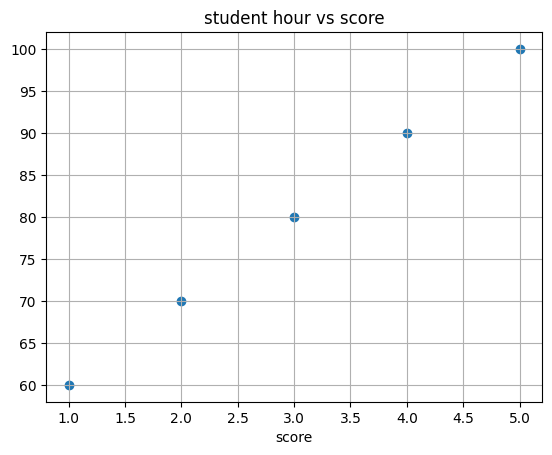

In [9]:
plt.Figure(figsize=(6,4))
plt.scatter(student_df["study_hours"],student_df["scores"])
plt.title("student hour vs score")
plt.xlabel("score")
plt.grid(True)
plt.show()

## 입력(X)과 정답(Y) 분리하기

- X: `study_hours`
- Y: `score`

In [11]:
X=student_df[['study_hours']]
y=student_df['scores']

print("X모양: ",X.shape)
print("y모양: ",y.shape)

X모양:  (5, 1)
y모양:  (5,)


## 훈련 데이터와 테스트 데이터 나누기

- 훈련 데이터: 모델이 규칙을 배우는 데이터
- 테스트 데이터: 모델이 처음 보는 데이터

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

print("훈련 데이터 개수:", len(X_train))
print("테스트 데이터 개수:", len(X_test))

훈련 데이터 개수: 3
테스트 데이터 개수: 2


## 선형 회귀 모델 학습

> 선형 회귀 모델(LinearRegression)은 입력값과 예측값 사이의 관계를 직선으로 표기하는 모델

공부시간 하나로 점수를 예측한다면, 아래와 같은 식을 찾습니다.

```
예측 점수=기울기 * 공부시간 + 절편
```

In [15]:
model=LinearRegression()
model.fit(X_train,y_train)

print("모델 학습 완료")
print("기울기:",model.coef_[0])
print("절편:",model.intercept_)

모델 학습 완료
기울기: 10.0
절편: 50.00000000000001


## 예측해보기

In [17]:
pred=model.predict(X_test)

result_df=X_test.copy()
result_df['actual_score']=y_test.values
result_df['predicted_score']=pred.round(1)
result_df["error"]=(result_df["actual_score"]-result_df["predicted_score"]).round(1)

result_df

,study_hours,actual_score,predicted_score,error
1,2,70,70.0,0.0
4,5,100,100.0,0.0


## 회귀 모델 평가 지표

**분류** 에서는 정확도(Accuracy)를 자주 사용했으나, 회귀에서는 예측값이 숫자이므로
*얼마나 틀렸는지를 봐야한다*

In [ ]:

#MAE-오차 절댓값 평균 -> 평균적으로 몇점 정도 틀리는가
#MSE-오차 제곱의 평균 -> 큰 오차를 더 강하게 벌점
#RMSE-MSE의 제곱근 -> 원래 단위로 해석가능
#R2-설명력 -> 1에 가까울수록 좋음
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=mse ** 0.5 
r2=r2_score(y_test,pred)

print(f"MAE:{mae:.2f}")
print(f"MSE:{mse:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2:{r2:.3f}")

MAE:0.00
MSE:0.00
RMSE:0.00
R2:1.000


## 회귀선 시각화 하기

산점도 위에 모델이 학습한 직선을 그린다.<br> 직선이 데이터 흐름을 잘 따라가면 선형 회귀가 잘 작동하고 있다고 볼 수 있다


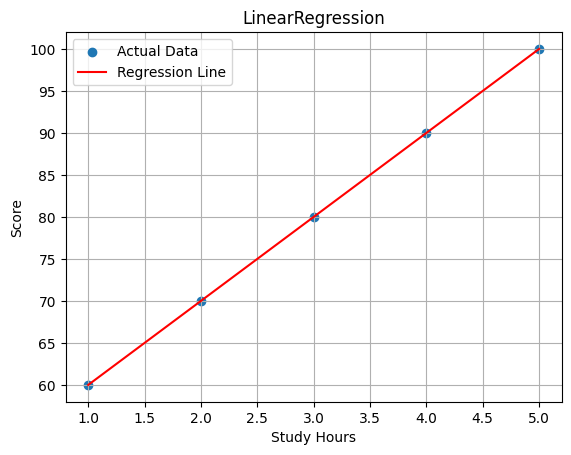

In [19]:
plt.Figure(figsize=(6,4))
plt.scatter(
    student_df["study_hours"],student_df["scores"],
    label="Actual Data"
)
x_line=pd.DataFrame({
    'study_hours':[
        student_df['study_hours'].min(),
        student_df['study_hours'].max()
    ]
})

y_line=model.predict(x_line)

plt.plot(
    x_line['study_hours'],y_line, color="red",
    label="Regression Line"
)
plt.title("LinearRegression")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## 새 데이터 예측하기

공부 시간 7.5시간 학생의 최종 점수를 예측해봅니다.

**주의사항**
- 학습할 때, `DataFrame` 형태로 넣었다면, 예측할 때도 같은 컬럼명을 가진 `DataFrame`을 넣어야 안전함
- 입력 컬럼의 순서와 학습할때와 같아야함


In [21]:
new_student=pd.DataFrame({
    'study_hours':[7.5]
})
predicted_score=model.predict(new_student)[0]

print(f"예상 점수: {predicted_score:.1f}점")

예상 점수: 125.0점
